In [31]:
# GAN >> DCGAN (CNN 도입해서 성능 개선)
# SRGAN(super resolution) 해상도 개선(오래된 사진 복원, 의료 영상)
# CycleGAN (스타일 변환) (2개의 생성기 사용) (여름 풍경 >> 겨울 풍경)

In [32]:
'''
# 판별기 학습
def train_discriminator(real_images, generator, discriminator, optimizer_d):
    # 진짜 이미지 판별
    real_output = discriminator(real_images)
    real_loss = F.binary_cross_entropy(real_output, torch.ones_like(real_output))

    # 가짜 이미지 생성 및 판별
    z = torch.randn(batch_size, latent_dim)
    fake_images = generator(z)
    fake_output = discriminator(fake_images.detach())
    fake_loss = F.binary_cross_entropy(fake_output, torch.zeros_like(fake_output))

    # 전체 손실
    d_loss = real_loss + fake_loss

    optimizer_d.zero_grad()
    d_loss.backward()
    optimizer_d.step()

# 생성기 학습
def train_generator(generator, discriminator, optimizer_g):
    z = torch.randn(batch_size, latent_dim)
    fake_images = generator(z)
    output = discriminator(fake_images)

    # 생성기는 판별기를 속이려고 함
    g_loss = F.binary_cross_entropy(output, torch.ones_like(output))

    optimizer_g.zero_grad()
    g_loss.backward()
    optimizer_g.step()
```

---
## DCGAN 소개

### DCGAN(Deep Convolutional GAN)

이제 GAN의 발전된 형태인 **DCGAN**을 배워보겠습니다!
DCGAN은 기본 GAN에 **CNN(Convolutional Neural Network)** 구조를 체계적으로 적용한 모델입니다.

#### 왜 DCGAN이 필요했을까?
기본 GAN의 문제점:
- 학습이 불안정 (기본적인 딥러닝 구조: DNN > 위치정보 없으니깐 노이즈 만들었는데 얼렁뚱땅.. 사람한테 뿔 달려있고)
- 고해상도 이미지 생성이 어려움
- 모드 붕괴(mode collapse) 현상 발생

DCGAN의 해결책:
- **합성곱 층** 사용으로 이미지의 공간적 특징 학습
- **배치 정규화(Batch Normalization)** 로 학습 안정화
- 체계적인 아키텍처 설계 지침 제공

---

## 7페이지: DCGAN 생성기 구조

### DCGAN 생성기의 상세 구조

생성기는 작은 노이즈 벡터(z)에서 시작해 점진적으로 이미지를 "키워나가는" 구조입니다. = 업샘플링

#### 단계별 과정:

1. **입력 단계**
```
   64차원 노이즈 → 선형 변환 → 16×16×128 특징 맵
```
   - 비유: 작은 씨앗(64차원)을 심어서 첫 새싹(16×16×128) 만들기

2. **업샘플링 1단계**
```
   16×16×128 → 32×32×128
```
   - 전치 합성곱(Transposed Convolution) 사용
   - 크기를 2배로 확대
   - 3×3 커널로 세밀한 특징 추가

3. **업샘플링 2단계**
```
   32×32×128 → 64×64×128
```
   - 다시 2배 확대
   - 더 세밀한 디테일 추가

4. **최종 출력**
```
   64×64×128 → 64×64×3 (RGB)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # 보통 stride=2하면 maxpooling 안하는 경우가 많음
        self.conv1 = nn.Conv2d(3, 64, 3, stride=2, padding=1)

        self.conv2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 512, 3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.fc = nn.Linear(512*4*4, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)

        x = x.view(x.size(0), -1)  # flatten
        x = torch.sigmoid(self.fc(x))

        return x

'''


'\n# 판별기 학습\ndef train_discriminator(real_images, generator, discriminator, optimizer_d):\n    # 진짜 이미지 판별\n    real_output = discriminator(real_images)\n    real_loss = F.binary_cross_entropy(real_output, torch.ones_like(real_output))\n   \n    # 가짜 이미지 생성 및 판별\n    z = torch.randn(batch_size, latent_dim)\n    fake_images = generator(z)\n    fake_output = discriminator(fake_images.detach())\n    fake_loss = F.binary_cross_entropy(fake_output, torch.zeros_like(fake_output))\n   \n    # 전체 손실\n    d_loss = real_loss + fake_loss\n   \n    optimizer_d.zero_grad()\n    d_loss.backward()\n    optimizer_d.step()\n   \n# 생성기 학습\ndef train_generator(generator, discriminator, optimizer_g):\n    z = torch.randn(batch_size, latent_dim)\n    fake_images = generator(z)\n    output = discriminator(fake_images)\n   \n    # 생성기는 판별기를 속이려고 함\n    g_loss = F.binary_cross_entropy(output, torch.ones_like(output))\n   \n    optimizer_g.zero_grad()\n    g_loss.backward()\n    optimizer_g.step()\n```\n\n---\

In [33]:
# 운영 체제와 상호 작용하는 함수(예: 파일 경로 처리)를 불러옴.
import os
# NumPy 라이브러리를 불러옴. 배열 및 수치 연산에 사용함.
import numpy as np

# PyTorch의 핵심 라이브러리를 불러옴.
import torch
# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn
# 함수형 신경망 연산(F) 모듈을 불러옴.
import torch.nn.functional as F
# PyTorch의 데이터 로더 유틸리티를 불러옴.
from torch.utils.data import DataLoader
# 자동 미분(Autograd)을 위한 Variable 클래스를 불러옴. (최신 PyTorch에서는 텐서가 대체함)
from torch.autograd import Variable

# TorchVision의 이미지 변환(transforms) 모듈을 불러옴. 데이터 전처리에 사용함.
import torchvision.transforms as transforms
# 텐서 이미지를 파일로 저장하는 유틸리티 함수를 불러옴.
from torchvision.utils import save_image
# TorchVision의 데이터셋 모듈을 불러옴.
from torchvision import datasets

In [34]:
# 총 학습 에폭(epoch) 횟수를 10으로 설정함.
num_eps=1
# 학습 시 사용할 미니 배치(batch) 크기를 32로 설정함.
bsize=32
# 옵티마이저의 학습률(learning rate)을 0.001로 설정함.
lrate=0.001
# 잠재 공간(latent space)의 차원(dimension)을 64로 설정함. (생성 모델의 입력 크기)
lat_dimension=64
# 입력 및 생성될 이미지의 크기(64x64)를 설정함.
image_sz=64
# 이미지의 채널 수(1: 흑백)를 설정함.
chnls=1
# 학습 진행 상황을 로그로 출력할 간격(미니 배치 수)을 200으로 설정함.
logging_intv=200

In [35]:
# GAN 생성자(Generator) 클래스 정의
class GanGenerator(nn.Module):
  def __init__(self):
    super(GanGenerator, self).__init__()

    # 선형 레이어의 출력 해상도 계산(예: 64x64 image 1/4 크기 = 16)
    self.inp_sz = image_sz // 4

    # 첫번째 layer : 잠재공간(latent space = lat_dimension)을 (128*inp_sz) 크기 벡터로 변환하는 선형 레이어 정의
    self.lin = nn.Linear(lat_dimension, 128*self.inp_sz*self.inp_sz)

    # 선형 레이어 출력 >> 배치 정규화
    self.bn1 = nn.BatchNorm2d(128)

    # 이미지 해상도를 2배로 업샘플링
    self.up1 = nn.Upsample(scale_factor=2)

    # 채널 128개 유지하는 3*3 커널 이용, 합성곱 layer 정의
    self.cn1 = nn.Conv2d(128, 128, 3, stride=1, padding=1)

    # 배치 정규화 레이어 정의(momentum=0.8 사용)
    self.bn2 = nn.BatchNorm2d(128, 0.8)

    # LeakyLeRU 활성화 함수 정의(음수 기울기 0.2 사용)
    self.rl1 = nn.LeakyReLU(0.2, inplace=True)

    # 이미지 해상도 2배 업샘플링
    self.up2 = nn.Upsample(scale_factor=2)

    # 채널을 128 >> 64개로 줄이는 3*3 합성곱 레이어 정의
    # 수정: 커널 크기 2 -> 3으로 변경하여 출력 크기를 유지하도록 함
    self.cn2 = nn.Conv2d(128, 64, 3, stride=1, padding=1)

    # 배치 정규화 레이어 정의(momentum=0.8 사용)
    self.bn3 = nn.BatchNorm2d(64, 0.8)

    # LeakyReLU 활성화 함수 정의(음수 기울기 0.2 사용)
    self.rl2 = nn.LeakyReLU(0.2, inplace=True)

    # 최종 채널 수를 chnls(1개)로 만드는 3*3 함성곱 레이어 정의
    self.cn3 = nn.Conv2d(64, chnls, 3, stride=1, padding=1)

    # 최종 출력 이미지 픽셀값을 [-1, 1] 범위로 제한 : Tahn 활성화 함수
    self.act = nn.Tanh()

  def forward(self, x):
    # 선형 레이어 통과
    x = self.lin(x)
    # 텐서를 (배치 크기, 채널, 높이, 너비) 4차원 형태로 재구성
    x = x.view(x.shape[0], 128, self.inp_sz, self.inp_sz)

    # 배치 정규화 1을 통과
    x = self.bn1(x)

    # 업샘플링 1 통과 >> 해상도 2배
    x = self.up1(x)

    # 합성곱 1 통과
    x = self.cn1(x)

    # 배치 정규화 2를 통과
    x = self.bn2(x)

    # Leaky ReLU 통과
    x = self.rl1(x)

    # 업샘플링 2 >> 해상도 2배
    x = self.up2(x)

    # 합성곱 2 통과
    x = self.cn2(x)

    # 배치 정규화 3 통과
    x = self.bn3(x)

    # Leaky Relu 통과
    x = self.rl2(x)

    # 최종 합성곱 레이어 3 통과
    x = self.cn3(x)

    # Tanh 활성화 함수 통과 >> 최종 출력 out
    out = self.act(x)

    return out

In [46]:
# GAN 판별자 (Discriminator) 클래스 정의
class GANDiscriminator(nn.Module):
  def __init__(self):
    super(GANDiscriminator, self).__init__()

    # 합성곱, leaky relu, dropout >> 하나의 판별 모듈 정의하는 헬퍼 함수
    def disc_module(ip_chnls, op_chnls, bnorm=True):
      # 3*3 합성곱, stride=2, padding=1 >> 해상도 절반으로 줄임
      mod = [nn.Conv2d(ip_chnls, op_chnls, 3, 2, 1),
             # 3: 3*3 커널, 2: stride, padding=1
             nn.LeakyReLU(0.2, inplace=True),
             # LeakyReLU 활성화 함수
             nn.Dropout2d(0.25) # 과적합 방지
             ]
      # 배치 정규화(bnorm)가 요청된 경우 모듈에 추가
      if bnorm:
        mod += [nn.BatchNorm2d(op_chnls, 0.8)]
        # mod.append(nn.BatchNorm2d(op_chnls, 0.8))

      return mod # 구성된 모듈 리스트 반환

    # 정의된 판별 모듈(disc_module)들을 연결하여 판별자 모델의 특징 추출부(disc_model) 구성
    self.disc_model = nn.Sequential(
        # 첫번째 모듈: 입력 채널(chnls)을 16개로 만들어줌. 배치 정규화 사용 X(False)
        # image_sz(32) >> 16
        # 첫 레이어만 BN 안함
        *disc_module(chnls, 16, bnorm=False), # *:unpacking

        # 두번째 모듈:16채널 >> 32채널 변환
        *disc_module(16, 32),

        # 세번째 모듈:32채널 >> 64채널 변환
        *disc_module(32, 64),

        # 네번째 모듈:64채널 >> 128채널 변환
        *disc_module(64, 128)
    )

    # 모델을 4번 통과한 후 해상도가 얼마나 줄었는지 계산
    # 예: 64 >> 32 >> 16 >> 8 >> 4
    # 4번의 다운샘플링 후 최종 해상도 계산
    ds_size = image_sz // (2 ** 4)

    # 특징맵을 단일 확률 값으로 변환하는 최종 레이어 정의
    self.adverse_lyr = nn.Sequential(
        nn.Linear(128*ds_size**2, 1),
        # 입력값 : 128*ds_size**2
        # 원래 128개 채널, ds_size*ds_size(feature map) >> 1차원 스칼라 변환 >> 하나의 출력값(벡터값)
        nn.Sigmoid() # 출력(0이면 가짜, 1이면 진짜)
    )

  # 순전파
  def forward(self, x):
    # 이미지 특징 추출부(disc_model) 통과
    # [중요] 반환된 특징맵을 변수 x에 다시 저장해야 합니다!
    x = self.disc_model(x)

    # 배치 차원 제외, 텐서 평탄화(flatten) >> 선형 레이어 입력 형태로 변환
    # flatten(view 활용)은 reshape 역할로 형태(구조)만 변화시키고 연산은 하지 않음
    x = x.view(x.shape[0], -1)
    # 4차원 텐서->(배치크기, 채널(c)*높이(h)*너비(w)):2차원 텐서

    # 최종 선형 및 sigmoid lyr 통과 >> 결과물(out) 얻음
    out = self.adverse_lyr(x)

    return out

In [48]:
gen = GanGenerator()
disc = GANDiscriminator()

# 손실함수(BCELoss) 이진 분류
adv_loss_func = torch.nn.BCELoss()

In [49]:
# MNIST 데이터셋 >> 데이터 로더
dloader = torch.utils.data.DataLoader(
              datasets.MNIST(
                  '/content/data/mnist',
            download=True, # 데이터 부재시 다운로드
            transform=transforms.Compose(
                [
                  transforms.Resize((image_sz, image_sz)),
                  # 이미지를 image_sz*image_sz(64*64) 조정
                  transforms.ToTensor(),
                  # 이미지 -> 텐서(0~1)
                  transforms.Normalize([0.5], [0.5])
                  # 픽셀 값 [-1, 1] 범위로 정규화(평균 0.5, 표준편차 0.5)
                ]
            ),
          ),
          batch_size = bsize,
          shuffle=True
)

# 생성자(gen) 모델 업데이트 위한 옵티마이저 정의
opt_gen = torch.optim.Adam(gen.parameters(), lr=lrate)
opt_disc = torch.optim.Adam(disc.parameters(), lr=lrate)

In [50]:
%pwd

'/content'

In [51]:
# 생성된 이미지를 저장한 디렉 설정
os.makedirs("/content/images_mnist", exist_ok=True)
# exist_ok=True : 디렉이 이미 존재하면 무시

In [52]:
for ep in range(num_eps):
  for idx, (images, _) in enumerate(dloader):
    # 데이터 로더를 돌면서(순회하면서) 미니배치(이미지, 레이블 무시) 처리

    # 진짜 이미지에 대한 정답 레이블(1,0) 텐서 생성(변화도 추적은 비활성화)
    # images.shape[0] : batch_size, [batch_size, 1]
    # good_img = Variable(torch.FloatTensor(images.shape[0], 1).fill_(1.0), requires_grad=False)
    good_img = torch.ones(images.size(0), 1)
    # 진짜 이미지에 대한 정답 레이블(1,0) 텐서 생성(변화도 추적은 비활성화)
    bad_img = Variable(torch.FloatTensor(images.shape[0], 1).fill_(0.0), requires_grad=False)
    # bad_img = torch.zeros(images.size(0), 1)

    # 실제 이미지를 pytorch float tensor 타입의 Variable로 변환
    actual_images = Variable(images.type(torch.FloatTensor))
    # actual_images = images.to(dtype=torch.float32)

    # 생성자(Generator) 훈련 단계
    opt_gen.zero_grad()

    # 정규 분포에서 random noise vector 생성 : lat_dimension 크기
    noise = Variable(torch.FloatTensor(np.random.normal(0, 1, (images.shape[0], lat_dimension))))
    # images.shape[0] 배치크기 (미니배치의 이미지 개수, lat_dimension: 잠재공간(latent space) 벡터의 차원 )
    # noise = torch.randn(images.size(0), lat_dimension)

    # 생성자 모델 G에 노이즈(z) 넣어서 가짜 이미지(gen_images) 생성
    gen_images = gen(noise)

    # 생성자 손실 계산 : 생성자 이미지를 진짜(good_img=1.0) 이라고 속일 수 있는가?
    generator_loss = adv_loss_func(disc(gen_images), good_img)

    # 생성자 손실 보면서 역전파 수행
    generator_loss.backward()

    # 생성자 파라미터 업데이트
    opt_gen.step()

    # 판별자 훈련
    opt_disc.zero_grad()

    # 실제 이미지에 대한 판별자 손실 계산 (전자를 진짜로 판단하도록)
    actual_images_loss = adv_loss_func(disc(actual_images), good_img)

    # 가짜 이미지에 대한 판별자 손실 계산(가짜를 가짜로 판단하도록)
    # gen_images.detach()로 생성자로부터 변화도 전파를 차단함.
    # detach: 훈련 못하게끔 함(얼마나 가짜인지 판단했는지 모르게)
    fake_image_loss = adv_loss_func(disc(gen_images.detach()), bad_img)

    # 판별자 손실을 진짜 손실과 가짜 손실의 평균 계산
    discriminator_loss = (actual_images_loss + fake_image_loss) / 2

    # 판별자 손실을 바탕으로 역전파 수행
    discriminator_loss.backward()

    # 판별자 파라미터 업데이트(w,b)
    opt_disc.step()

    # 현재까지 완료된 배치의 총 개수 계산
    batches_completed = ep * len(dloader) + idx
    # 현재 진행중인 에폭(한번 학습) * 총 배치 수 + 현재 에폭 내에서 진행 중인 배치 인덱스

    # 로깅 간격(logging_intv) 마다 현재 손실 출력하고 이미지 저장
    if batches_completed % logging_intv == 0:
      print(f'epoch number {ep} | batch number {idx} | generator loss = {generator_loss.item()} | discriminator loss = {discriminator_loss.item()}')
      # 생성된 이미지 25개(5*5 그리드)
      save_image(gen_images.data[:25], f"images_mnist/{batches_completed}.png", nrow=5, normalize=True)


epoch number 0 | batch number 0 | generator loss = 0.6983746290206909 | discriminator loss = 0.6930140256881714
epoch number 0 | batch number 200 | generator loss = 0.9802770018577576 | discriminator loss = 0.8147329688072205
epoch number 0 | batch number 400 | generator loss = 1.1033084392547607 | discriminator loss = 0.5109618902206421
epoch number 0 | batch number 600 | generator loss = 0.7563076019287109 | discriminator loss = 0.5656389594078064
epoch number 0 | batch number 800 | generator loss = 1.5765362977981567 | discriminator loss = 0.566504716873169
epoch number 0 | batch number 1000 | generator loss = 1.541707992553711 | discriminator loss = 0.16296350955963135
epoch number 0 | batch number 1200 | generator loss = 1.7729332447052002 | discriminator loss = 0.5195899605751038
epoch number 0 | batch number 1400 | generator loss = 2.013150691986084 | discriminator loss = 0.3617343008518219
epoch number 0 | batch number 1600 | generator loss = 2.9775118827819824 | discriminator 

In [53]:
import os
import natsort # 자연 정렬 모듈

# --- 경로 설정 (실제 환경에 맞게 조정 필요) ---
image_dir = '/content/images_mnist'
# 만약 Windows 환경이라면: image_dir = 'C:/Users/username/Desktop/images_mnist' 등으로 변경 필요

# 1. 디렉터리 내 파일 목록을 가져와 natsort로 자연 정렬 (예: image1, image2, image10 순서로 정렬)
# 1, 10, 5 ---> 1, 5, 10
sorted_files = natsort.natsorted(os.listdir(image_dir))

# 2. 정렬된 파일명에 디렉터리 경로를 결합하여 최종 경로 리스트 생성
image_list = [os.path.join(image_dir, x) for x in sorted_files]
# /content/images_mnist/1.png

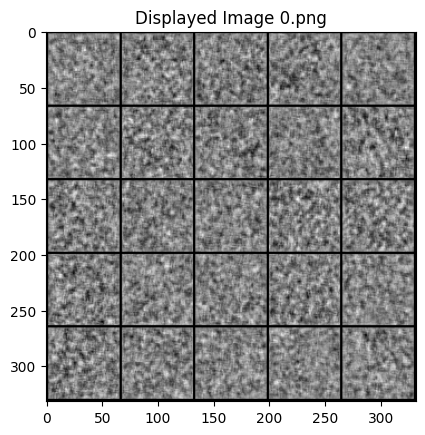

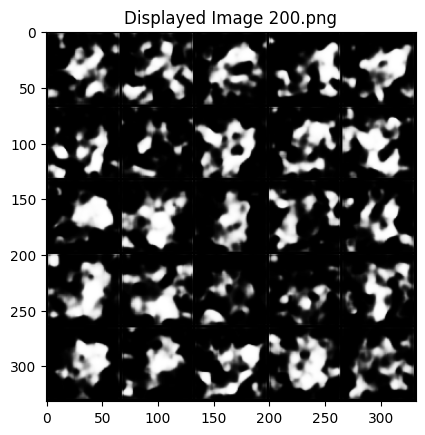

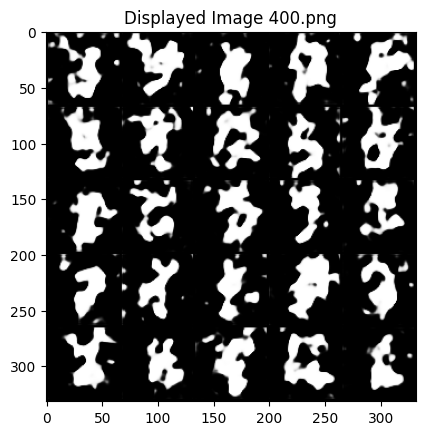

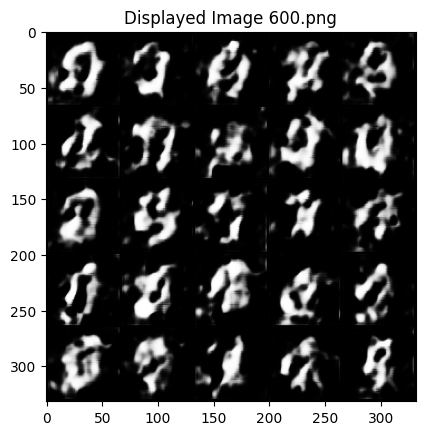

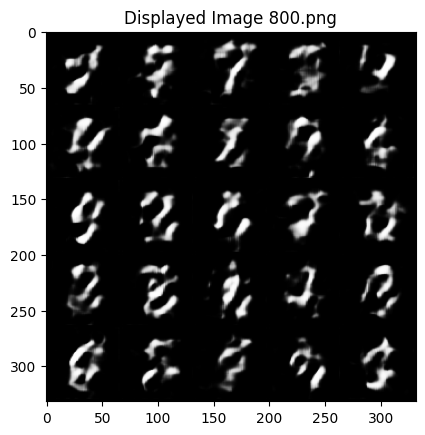

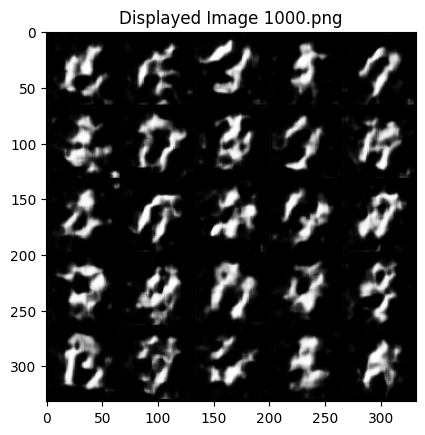

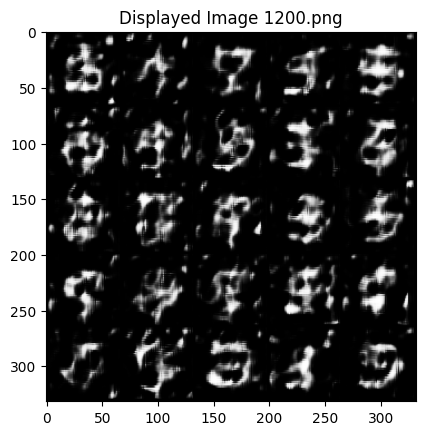

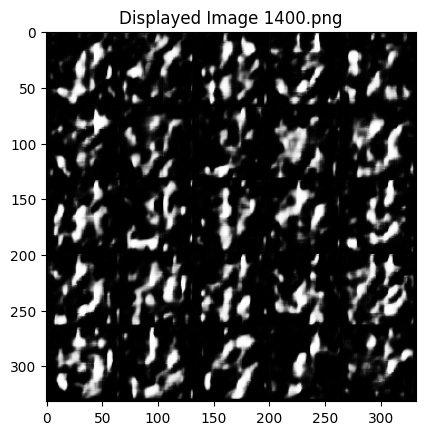

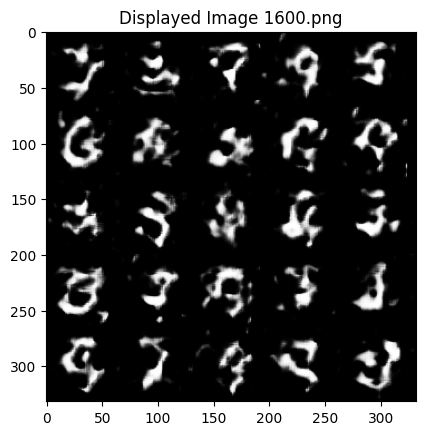

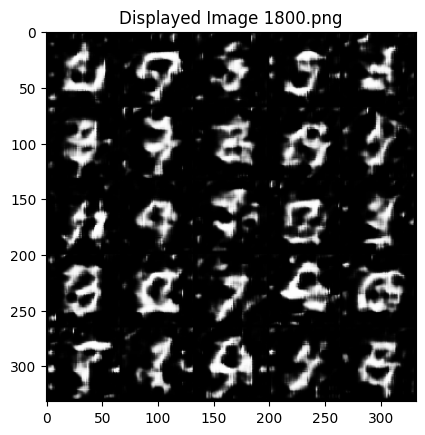

In [54]:
import cv2
import matplotlib.pyplot as plt

loaded_images = []

for path in image_list:
  img = cv2.imread(path)

  if img is None:
    print(f'경로에 오류가 있어 파일을 찾을 수 없습니다.: {path}')
    continue
    # 이미지 로드 못했으면 건너뛰기

  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  loaded_images.append(img_rgb)

for i in range(len(loaded_images)):
  plt.figure()
  plt.imshow(loaded_images[i])
  plt.title(f'Displayed Image {image_list[i].split('/')[-1]}')

plt.show()